In [2]:
# init
import importlib, sys

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# breaking

In [4]:
# # seetings
# data = np.load("breaking/eva.npz")
# V_mV = data["Vbias_mV"]
# Iexp_nA = data["Iup_nA"]
# x_arbu = data["x_arbu"]
# settings = {
#     "tau_1": (0.01, 0.00, 1.00, False),
#     "tau_2": (0.01, 0.00, 1.00, False),
#     "tau_3": (0.01, 0.00, 1.00, False),
#     "tau_4": (0.01, 0.00, 1.00, False),
#     "tau_5": (0.01, 0.00, 1.00, False),
#     "tau_6": (0.01, 0.00, 1.00, False),
#     "tau_7": (0.01, 0.00, 1.00, False),
#     "tau_8": (0.00, 0.00, 1.00, False),
#     "tau_9": (0.00, 0.00, 1.00, False),
#     "tau_A": (0.00, 0.00, 1.00, True),
#     "tau_B": (0.00, 0.00, 1.00, True),
#     "tau_C": (0.00, 0.00, 1.00, True),
#     "T_K": (0.00, 0.00, 1.21, True),
#     "Delta_meV": (0.1885, 0.187, 0.191, False),
#     "gamma_meV": (1e-6, 1e-6, 1e-2, True),
#     "sigmaV_mV": (0.026, 0.01, 0.04, False),
# }
# restarts = 10
# Vnan_mV = 0.04
# tau_sum_bounds = (0.0, 5.0)

In [5]:
# # fit all data (steepest gradient)
# import numpy as np
# from mar_fit import fit_mar

# # load data

# weights = np.where(1 / V_mV, V_mV != 0, 0.0)
# mask = np.abs(V_mV) <= Vnan_mV
# I_nA = np.copy(Iexp_nA)
# I_nA[:, mask] = np.nan
# results = fit_mar(
#     I_nA[:3, :],
#     "grid.pkl",
#     settings=settings,
#     tau_sum_bounds=tau_sum_bounds,
#     restarts=restarts,
#     progress=True,
# )
# Ifit_nA = np.full_like(I_nA)
# taus = np.full((I_nA.shape[0], 12), np.nan)
# T_K = np.full((I_nA.shape[0]), np.nan)
# Delta_meV = np.full((I_nA.shape[0]), np.nan)
# gamma_meV = np.full((I_nA.shape[0]), np.nan)
# sigmaV_mV = np.full((I_nA.shape[0]), np.nan)

# for i, result in enumerate(results):
#     Ifit_nA[i, :] = result.Ifit_nA
#     T_K[i] = result.T_K
#     Delta_meV[i, :] = result.Delta_meV
#     gamma_meV[i, :] = result.gamma_meV
#     sigmaV_mV[i, :] = result.sigmaV_mV

# GN_G0 = np.nansum(taus, axis=-1)
# np.savez(
#     "breaking/fit_data.npz",
#     V_mV=V_mV,
#     x_arbu=x_arbu,
#     Iexp_nA=I_nA,
#     Ifit_nA=Ifit_nA,
#     taus=taus,
#     GN_G0=GN_G0,
#     T_K=T_K,
#     Delta_meV=Delta_meV,
#     gamma_meV=gamma_meV,
#     sigmaV_mV=sigmaV_mV,
#     results=results,
#     mask=mask,
#     weights=weights,
#     settings=settings,
#     tau_sum_bounds=tau_sum_bounds,
# )

# $550 G_0$

In [49]:
# magnetic field
data = np.load(f"550G0/magnetic-field/eva.npz")
Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]
Tbath_K = data["Tbath_K"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]
Iexp_nA = data["Iexp_nA"]
Vexp_mV = data["Vexp_mV"]
uH_mT = data["uH_mT"]

uHc_mT = 9.95
Tc_K = 1.21
Ic_nA = 1.075e6
RN_Ohm = 23.5

uH_mT += 0.55
uH = uH_mT / uHc_mT
Vbias = Vbias_mV * 1e6 / RN_Ohm / Ic_nA
Vexp = Vexp_mV * 1e6 / RN_Ohm / Ic_nA
Ibias = Ibias_nA / Ic_nA
Iexp = Iexp_nA / Ic_nA
dGexp = dGexp_G0 * sc.G0_muS * 1e-6 * RN_Ohm
dRexp = dRexp_R0 / sc.G0_muS * 1e6 / RN_Ohm

np.savez(
    f"550G0/magnetic-field/cal.npz",
    Vbias=Vbias,
    Ibias=Ibias,
    uH=uH,
    Iexp=Iexp,
    Vexp=Vexp,
    dGexp=dGexp,
    dRexp=dRexp,
)

# $0.05 G_0$

In [66]:
# # temperature, magnetic field
data = np.load(f"0.05G0/temperature/eva.npz")
Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]
Tbath_K = data["Tbath_K"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]
Iexp_nA = data["Iexp_nA"]

Tc_K = 1.21
Delta_meV = 0.1885
GN_G0 = 0.13367895134953922

Vbias = Vbias_mV / Delta_meV
Ibias = Ibias_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Tbath = Tbath_K / Tc_K
Iexp = Iexp_nA / (Delta_meV * GN_G0 * sc.G0_muS)
dGexp = dGexp_G0 / GN_G0
dRexp = dRexp_R0 * GN_G0

np.savez(
    f"0.05G0/temperature/cal.npz",
    Vbias=Vbias,
    Ibias=Ibias,
    Tbath=Tbath,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
)

data = np.load(f"0.05G0/magnetic-field/eva.npz")
Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]
Tbath_K = data["Tbath_K"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]
Iexp_nA = data["Iexp_nA"]
uH_mT = data["uH_mT"]

uHc_mT = 28
Tc_K = 1.21
Delta_meV = 0.1885
GN_G0 = 0.04837291812646421

Vbias = Vbias_mV / Delta_meV
Ibias = Ibias_nA / (Delta_meV * GN_G0 * sc.G0_muS)
uH = uH_mT / uHc_mT
Iexp = Iexp_nA / (Delta_meV * GN_G0 * sc.G0_muS)
dGexp = dGexp_G0 / GN_G0
dRexp = dRexp_R0 * GN_G0

np.savez(
    f"0.05G0/magnetic-field/cal.npz",
    Vbias=Vbias,
    Ibias=Ibias,
    uH=uH,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
)

In [67]:
# fit PAT
data = np.load("0.05G0/15.0GHz_stripline/eva.npz")
Vbias_mV = data["Vbias_mV"]
Iexp_nA = data["Iexp_nA"]
Aout_mV = data["Aout_mV"]

# presetting
GN_G0 = 0.05145269536583475
T_K = 0.0
Delta_meV = 0.19528636461486773
gamma_meV = 1e-9
sigmaV_mV = 0.03259529391192322

settings = {
    "GN_G0": (GN_G0, 0.1, 0.3, True),
    "T_K": (T_K, 0.0, 1.5, True),
    "Delta_meV": (Delta_meV, 0.180, 0.210, True),
    "gamma_meV": (gamma_meV, 1e-9, 25e-3, True),
    "sigmaV_mV": (sigmaV_mV, 0.0, 2.0, True),
    "A_mV": (0.0001, 0.0, 2.0, False),
    "nu_GHz": (15.0, 1.0, 20.0, True),
}

import numpy as np
from tqdm import tqdm

from bcs_fit import fit_bcs_conv_noise, print_bcs_comparison_table

n_curves = Iexp_nA.shape[0]

Ifit_nA = np.full_like(Iexp_nA, np.nan, dtype=float)
parameter_names = tuple(settings)
fit_values = {name: np.full(n_curves, np.nan) for name in parameter_names}
fit_errors = {name: np.full(n_curves, np.nan) for name in parameter_names}

for i in tqdm(range(n_curves), desc="BCS fits"):

    fit_row, solution = fit_bcs_conv_noise(
        Vbias_mV,
        Iexp_nA[i, :],
        dict(settings),
        maxfev=20_000,
    )
    Ifit_nA[i, :] = solution["I_fit_nA"]
    for parameter in solution["params"]:
        fit_values[parameter.name][i] = parameter.value
        fit_errors[parameter.name][i] = parameter.error

GN_G0, T_K, Delta_meV, gamma_meV, sigmaV_mV, A_mV, nu_GHz = (
    fit_values[name] for name in parameter_names
)
uGN_G0, uT_K, uDelta_meV, ugamma_meV, usigmaV_mV, uA_mV, unu_GHz = (
    fit_errors[name] for name in parameter_names
)
eta = np.nanmedian(A_mV / Aout_mV)
np.savez(
    "0.05G0/15.0GHz_stripline/fit_pat.npz",
    Vbias_mV=Vbias_mV,
    Iexp_nA=Iexp_nA,
    Ifit_nA=Ifit_nA,
    eta=eta,
    GN_G0=GN_G0,
    T_K=T_K,
    Delta_meV=Delta_meV,
    gamma_meV=gamma_meV,
    sigmaV_mV=sigmaV_mV,
    A_mV=A_mV,
    nu_GHz=nu_GHz,
    uGN_G0=uGN_G0,
    uT_K=uT_K,
    uDelta_meV=uDelta_meV,
    ugamma_meV=ugamma_meV,
    usigmaV_mV=usigmaV_mV,
    uA_mV=uA_mV,
    unu_GHz=unu_GHz,
)

BCS fits: 100%|██████████| 32/32 [00:33<00:00,  1.06s/it]
/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_24540/966635376.py:55: RuntimeWarning: divide by zero encountered in divide
  eta = np.nanmedian(A_mV / Aout_mV)


In [92]:
# fit mar
import numpy as np
from mar_fit import fit_mar
from superconductivity.utilities.functions.upsampling import upsample

# load data
path = "0.05G0/15.0GHz_stripline"
data = np.load(f"{path}/eva.npz")
V_mV = data["Vbias_mV"]
I_nA = data["Iexp_nA"][0, :]
Vbins_mV = np.linspace(-0.9, 0.9, 1801)
Iexp_nA = sc.nanbin_y_over_x(upsample(I_nA), upsample(V_mV), Vbins_mV)

# from mar_fit import MARGrid, prepare_mar_database

# grid = MARGrid(
#     V_mV=Vbins_mV,
#     tau=np.linspace(0, 0.06, 61),
#     T_K=np.linspace(0, 0.6, 21),
#     Delta_meV=np.linspace(0.188, 0.196, 9),
#     # gamma_meV=np.linspace(0, 10e-3, 11),
#     gamma_meV=0,
#     sigmaV_mV=np.linspace(0, 0.04, 81),
# )
# database = prepare_mar_database(grid)

settings = {
    "tau_1": (0.05, 0.00, 1.00, False),
    "tau_2": (0.00, 0.00, 1.00, True),
    "tau_3": (0.00, 0.00, 1.00, True),
    "tau_4": (0.00, 0.00, 1.00, True),
    "tau_5": (0.00, 0.00, 1.00, True),
    "tau_6": (0.00, 0.00, 1.00, True),
    "tau_7": (0.00, 0.00, 1.00, True),
    "tau_8": (0.00, 0.00, 1.00, True),
    "tau_9": (0.00, 0.00, 1.00, True),
    "tau_A": (0.00, 0.00, 1.00, True),
    "tau_B": (0.00, 0.00, 1.00, True),
    "tau_C": (0.00, 0.00, 1.00, True),
    "T_K": (0.00, 0.00, 1.21, False),
    "Delta_meV": (0.1885, 0.187, 0.191, False),
    "gamma_meV": (1e-3, 0, 10e-3, False),
    "sigmaV_mV": (0.026, 0.00, 0.04, False),
}
restarts = 1000
Vnan_mV = 0.04
tau_sum_bounds = (0.0, 0.1)

weights = np.divide(
    1,
    np.abs(V_mV),
    out=np.full_like(V_mV, 0),
    where=V_mV != 0.0,
)
# mask = np.abs(V_mV) <= Vnan_mV
mask = np.full_like(V_mV, True)

result = fit_mar(
    Iexp_nA,
    "grid.pkl",
    settings=settings,
    tau_sum_bounds=tau_sum_bounds,
    restarts=restarts,
    progress=True,
)
Ifit_nA = result.Ifit_nA
tau = result.tau
T_K = result.T_K
Delta_meV = result.Delta_meV
gamma_meV = result.gamma_meV
sigmaV_mV = result.sigmaV_mV
GN_G0 = np.nansum(tau, axis=-1)

print("GN_G0", GN_G0)
print("tau", tau)
# print("T_K", T_K)
print("Delta_meV", Delta_meV)
# print("gamma_meV", gamma_meV)
print("sigmaV_mV", sigmaV_mV)
np.savez(
    f"{path}/fit_data.npz",
    V_mV=Vbins_mV,
    Iexp_nA=I_nA,
    Ifit_nA=Ifit_nA,
    tau=tau,
    GN_G0=GN_G0,
    T_K=T_K,
    Delta_meV=Delta_meV,
    gamma_meV=gamma_meV,
    sigmaV_mV=sigmaV_mV,
    result=result,
    mask=mask,
    weights=weights,
    settings=settings,
    tau_sum_bounds=tau_sum_bounds,
)

MAR curves:   0%|          | 0/11529 [00:00<?, ?curve/s]

KeyboardInterrupt: 

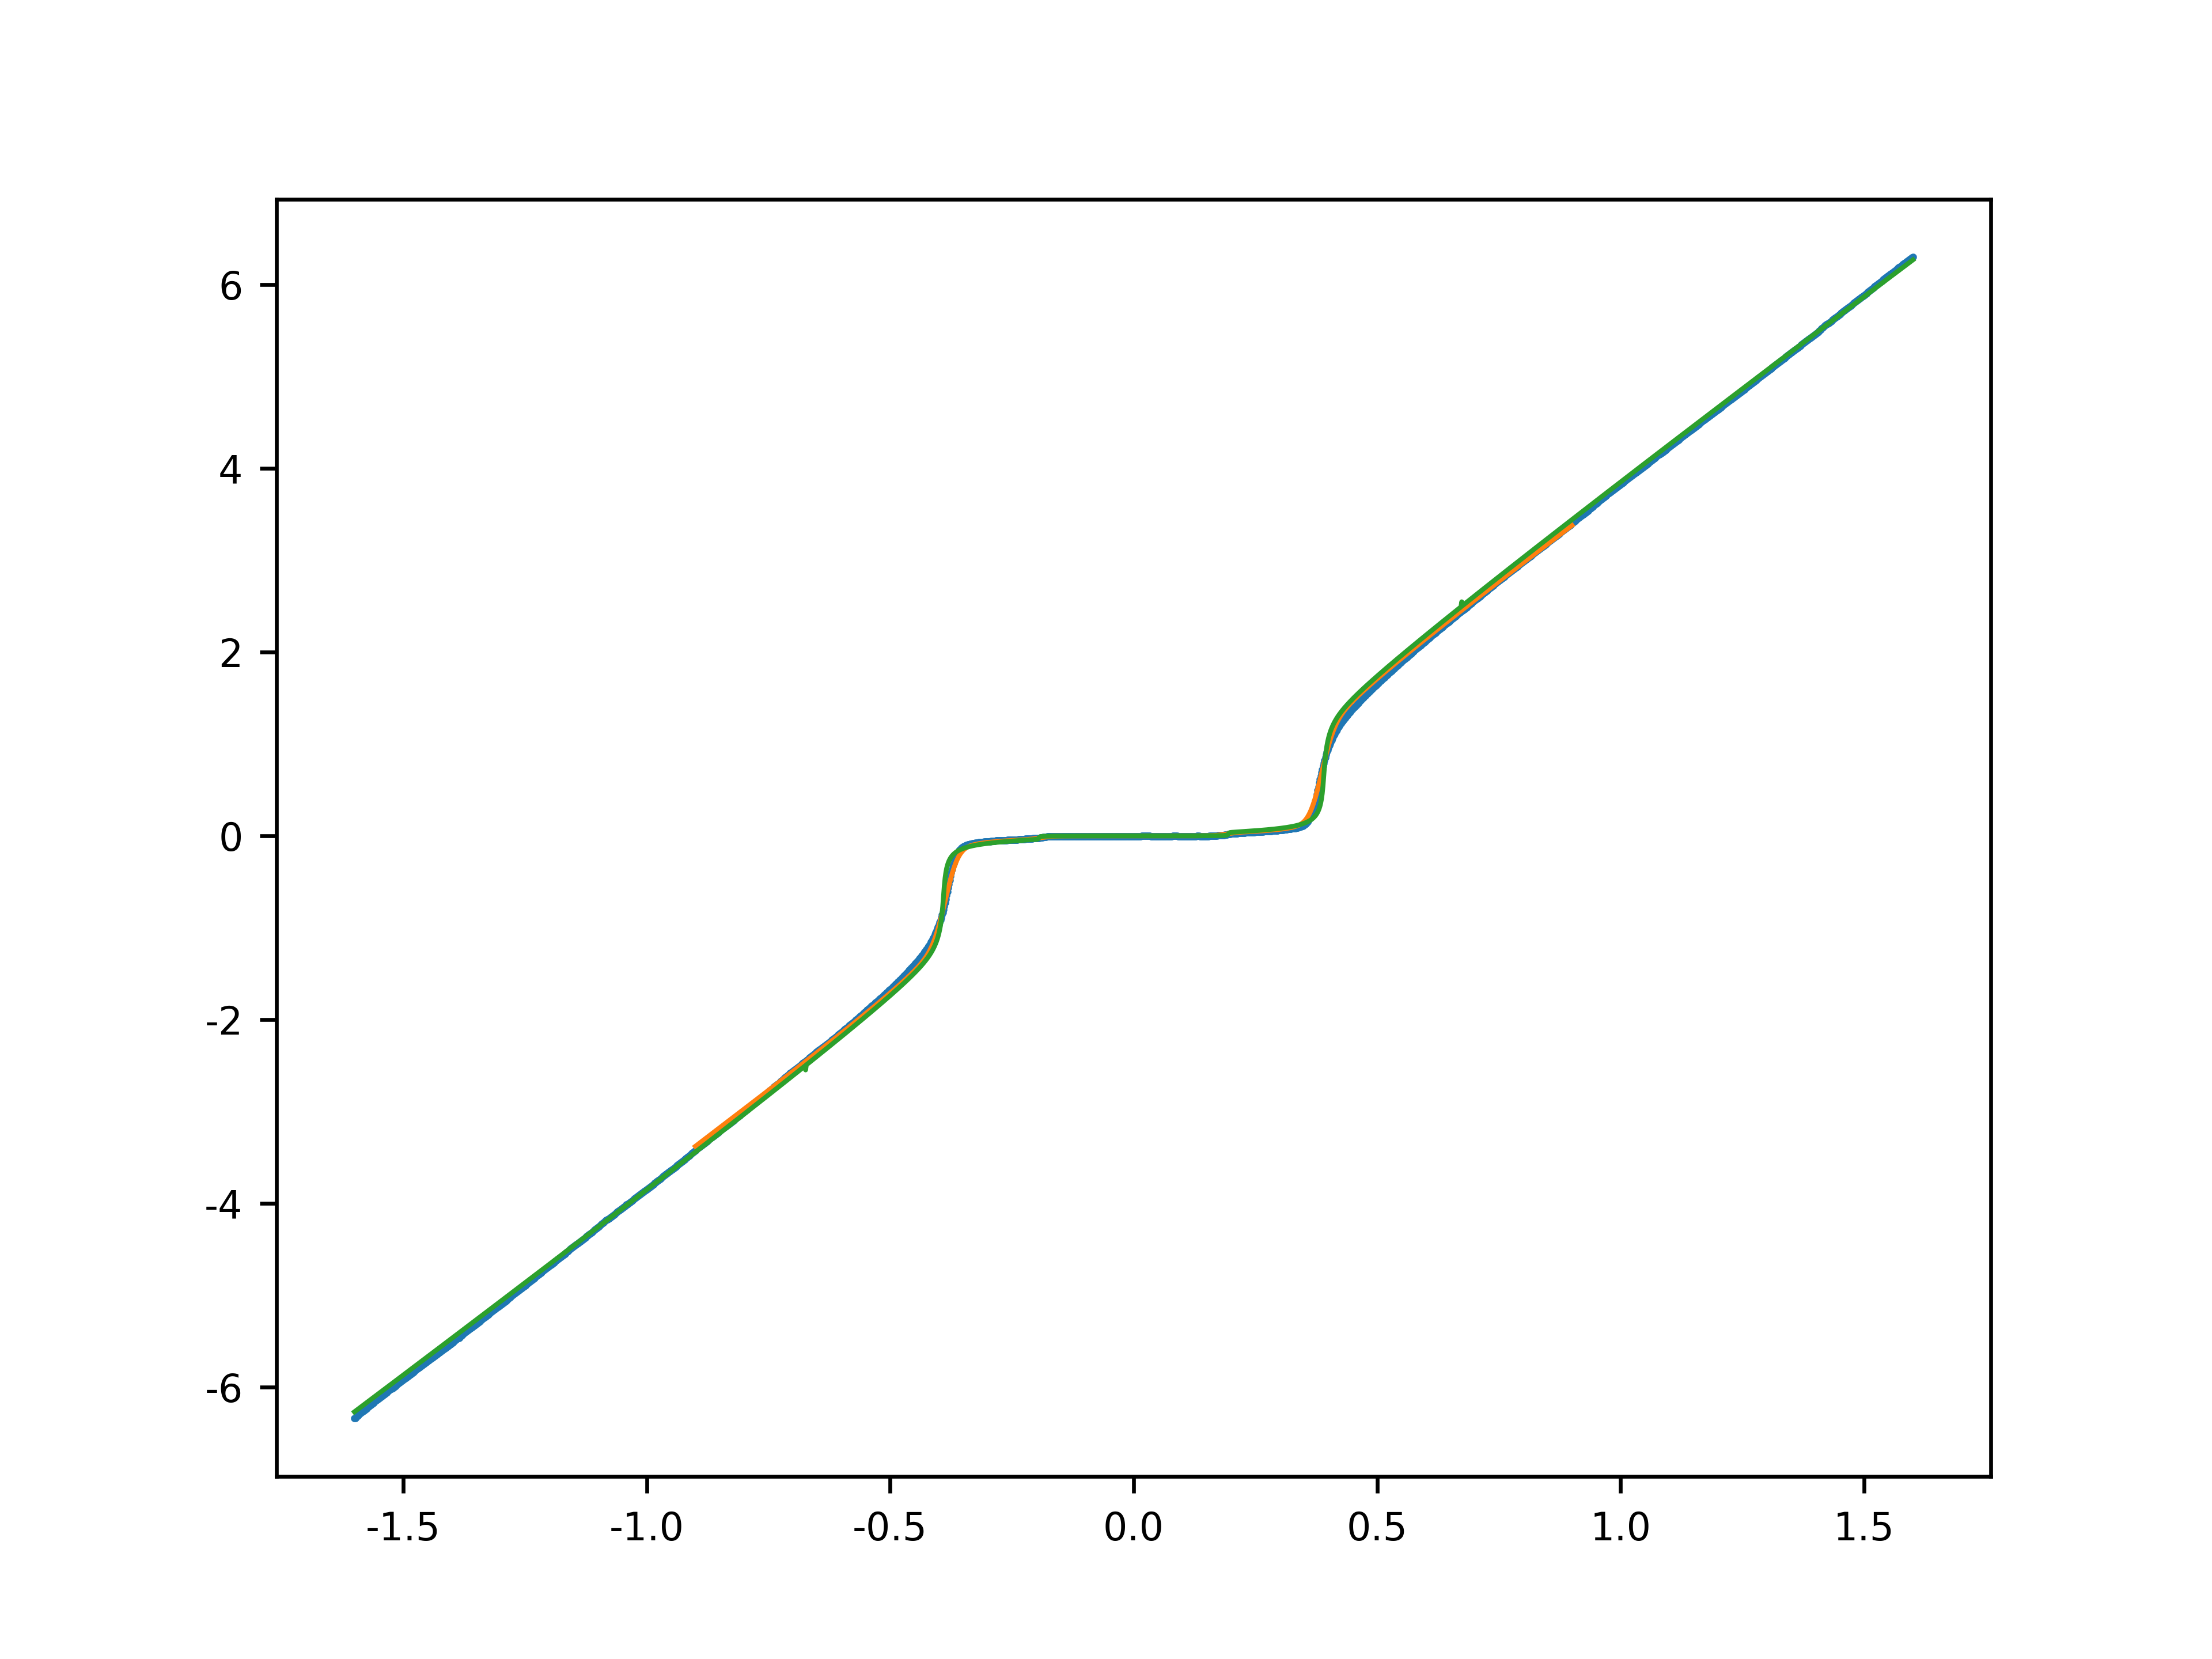

In [87]:
Isim_nA = sc.get_Imar_nA(V_mV, tau=0.051, T_K=0.0, Delta_meV=0.195, gamma_meV=1e-3)

plt.plot(V_mV, I_nA, ".")
plt.plot(Vbins_mV, Ifit_nA)
plt.plot(V_mV, Isim_nA)

model           ok    rmse_nA    GN_G0      T_K       Delta_meV  gamma_meV   sigmaV_mV
--------------  ----  ---------  ---------  --------  ---------  ----------  ---------
bcs_conv_noise  True  0.0268325  0.0514529  0.396949  0.196928   0.00586996  0.0143783
GN_G0 0.05145269536583475 0.05145292897677959 9.041617969050742e-06
T_K 0.0 0.3969488504633424 0.02438277470649035
Delta_meV 0.19479995314857806 0.19692797539578646 0.0004462449650444754
gamma_meV 1e-09 0.005869961216691512 0.00021072024837347737
sigmaV_mV 0.005471479250369344 0.01437831958711374 0.0007722084895949962
Tbath_K 0.04029809782608696


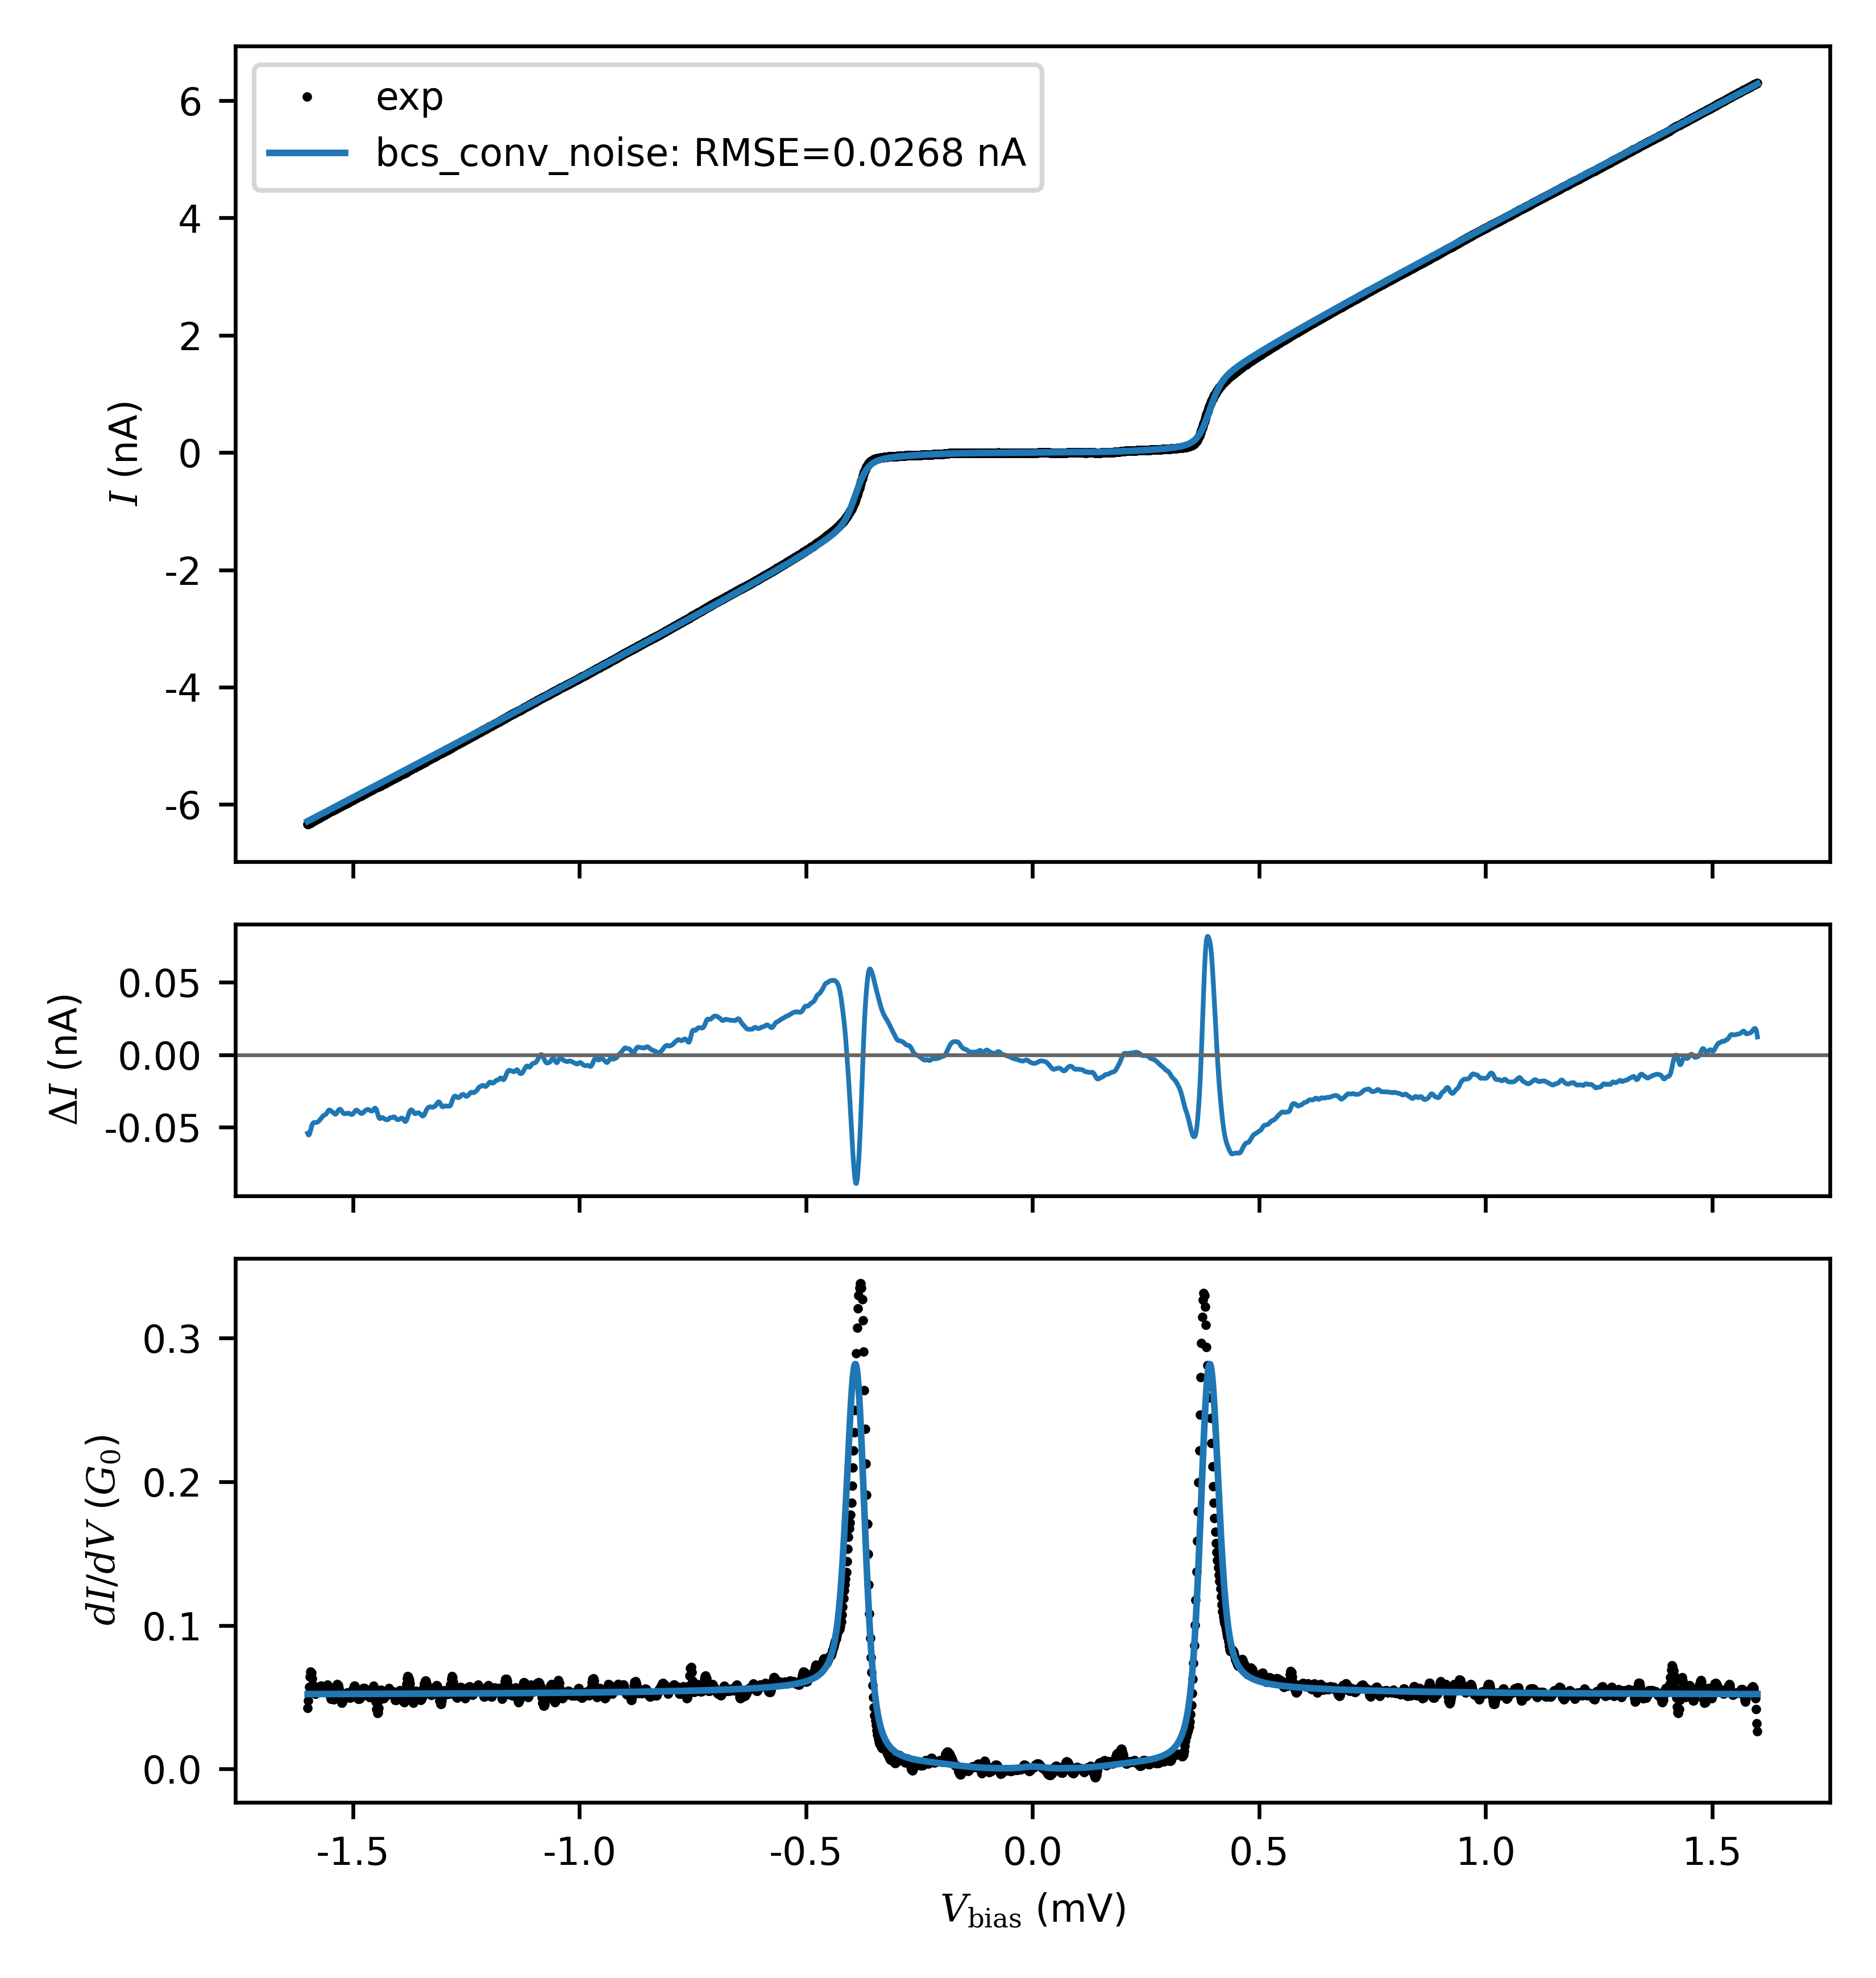

In [89]:
# single IV fit
data = np.load("0.05G0/15.0GHz_stripline/eva.npz")
V_mV = data["Vbias_mV"]
I_nA = data["Iexp_nA"][0, :]
Tbath_K = data["Tbath_K"][0]
GN_G0 = 0.05145269536583475
T_K = 0.0
Delta_meV = 0.19479995314857806
gamma_meV = 1e-9
sigmaV_mV = 0.005471479250369344

settings = {
    "GN_G0": (GN_G0, 0.0, 0.1, False),
    "T_K": (T_K, 0.0, 1.2, False),
    "Delta_meV": (Delta_meV, 0.180, 0.210, False),
    "gamma_meV": (gamma_meV, 1e-9, 25e-3, False),
    "sigmaV_mV": (sigmaV_mV, 0.0, 1.0, False),
    "A_mV": (0.0, 0.0, 4.0, True),
    "nu_GHz": (15.0, 1.0, 20.0, True),
}

# fit only the noise-capable model
from bcs_fit import fit_bcs_conv_noise
from compare_bcs_fits import plot_bcs_conv_noise_fit, print_bcs_comparison_table

fit_row, noise_solution = fit_bcs_conv_noise(
    V_mV,
    I_nA,
    settings,
    maxfev=20_000,
)

print_bcs_comparison_table(
    [fit_row],
    columns=(
        "model",
        "ok",
        "rmse_nA",
        "GN_G0",
        "T_K",
        "Delta_meV",
        "gamma_meV",
        "sigmaV_mV",
    ),
)

Ifit_nA = noise_solution["I_fit_nA"]
fit_values = {parameter.name: parameter.value for parameter in noise_solution["params"]}
fit_errors = {parameter.name: parameter.error for parameter in noise_solution["params"]}

fig = plot_bcs_conv_noise_fit(fit_row, noise_solution)

print("GN_G0", GN_G0, fit_values["GN_G0"], fit_errors["GN_G0"])
print("T_K", T_K, fit_values["T_K"], fit_errors["T_K"])
print("Delta_meV", Delta_meV, fit_values["Delta_meV"], fit_errors["Delta_meV"])
print("gamma_meV", gamma_meV, fit_values["gamma_meV"], fit_errors["gamma_meV"])
print("sigmaV_mV", sigmaV_mV, fit_values["sigmaV_mV"], fit_errors["sigmaV_mV"])
print("Tbath_K", Tbath_K)

# # saving fit data
# np.savez_compressed(
#     "single_iv/fit.npz",
#     V_mV=V_mV,
#     Iexp_nA=I_nA,
#     Ifit_nA=Ifit_nA,
#     GN_G0=GN_G0,
#     T_K=T_K,
#     Delta_meV=Delta_meV,
#     gamma_meV=gamma_meV,
#     sigmaV_mV=sigmaV_mV,
# )